In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/kaggle/input/heartdatasetclinical/cardio_train.csv", sep=';')

# Feature engineering
df["age_years"] = (df["age"] / 365).round(1)
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

df["gender"] = df["gender"].map({1: "Female", 2: "Male"})
df["cholesterol"] = df["cholesterol"].map({1: "Normal", 2: "Above Normal", 3: "Well Above Normal"})
df["gluc"] = df["gluc"].map({1: "Normal", 2: "Above Normal", 3: "Well Above Normal"})
df["cardio"] = df["cardio"].map({0: "No Disease", 1: "Has Disease"})

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams.update({
    "axes.labelweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def save_fig(name):
    plt.tight_layout(pad=1.2)
    plt.savefig(f"{name}.png", bbox_inches='tight')
    plt.close()

# Helper function to show count labels
def annotate_bars(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9, color='black')

plt.figure(figsize=(5,4))
ax = sns.countplot(data=df, x="cardio", palette="Set2", edgecolor="black")
plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardiovascular Condition")
plt.ylabel("Count")
annotate_bars(ax)
save_fig("01_class_distribution")

plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="age_years", hue="cardio", fill=True, common_norm=False,
            palette="crest", alpha=0.7)
plt.title("Age Distribution by Cardiovascular Status")
plt.xlabel("Age (Years)")
plt.ylabel("Density")
save_fig("02_age_distribution")

plt.figure(figsize=(6,4))
sns.regplot(data=df, x="age_years", y="BMI", scatter_kws={"alpha":0.3, "s":15}, line_kws={"color":"red"})
plt.title("Relationship between Age and BMI")
plt.xlabel("Age (Years)")
plt.ylabel("Body Mass Index (BMI)")
save_fig("03_age_vs_bmi")
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="cardio", y="ap_hi", palette="pastel", width=0.5)
plt.title("Systolic Blood Pressure vs Cardiovascular Status")
plt.xlabel("Cardiovascular Status")
plt.ylabel("Systolic BP (mmHg)")
save_fig("04_bp_vs_cardio")

fig, axes = plt.subplots(1, 2, figsize=(10,4))

ax1 = sns.countplot(data=df, x="cholesterol", hue="cardio", ax=axes[0],
                    palette="viridis", edgecolor="black")
axes[0].set_title("Cholesterol vs Cardiovascular Status")
axes[0].set_xlabel("Cholesterol Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=20)
annotate_bars(ax1)

ax2 = sns.countplot(data=df, x="gluc", hue="cardio", ax=axes[1],
                    palette="mako", edgecolor="black")
axes[1].set_title("Glucose vs Cardiovascular Status")
axes[1].set_xlabel("Glucose Level")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=20)
annotate_bars(ax2)

plt.tight_layout()
save_fig("05_chol_gluc_vs_cardio")
lifestyle = df.melt(id_vars=["cardio"], value_vars=["smoke", "alco", "active"],
                    var_name="Lifestyle Factor", value_name="Value")

plt.figure(figsize=(6,4))
ax = sns.countplot(data=lifestyle, x="Lifestyle Factor", hue="cardio", palette="coolwarm", edgecolor="black")
plt.title("Lifestyle Habits vs Cardiovascular Status")
plt.ylabel("Count of Individuals")
plt.xlabel("Lifestyle Behavior")
annotate_bars(ax)
save_fig("06_lifestyle_vs_cardio")

plt.figure(figsize=(6,5))
corr = df[["age_years","height","weight","ap_hi","ap_lo","BMI"]].corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink":0.7})
plt.title("Correlation Matrix of Continuous Features")
save_fig("07_correlation_heatmap")

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="age_years", y="BMI", hue="cardio",
                alpha=0.5, s=25, palette="coolwarm", edgecolor=None)
plt.title("Age vs BMI by Cardiovascular Status")
plt.xlabel("Age (Years)")
plt.ylabel("BMI")
plt.legend(title="Cardio", frameon=True)
save_fig("08_age_bmi_cardio_relationship")

print("✅ All visualizations saved (PNG, 400 DPI) with bar count annotations.")

✅ Using device: cuda
[LightGBM] [Info] Number of positive: 27983, number of negative: 28017
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1067
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 14
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (0.64 MB) transferred to GPU in 0.001321 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499696 -> initscore=-0.001214
[LightGBM] [Info] Start training from score -0.001214


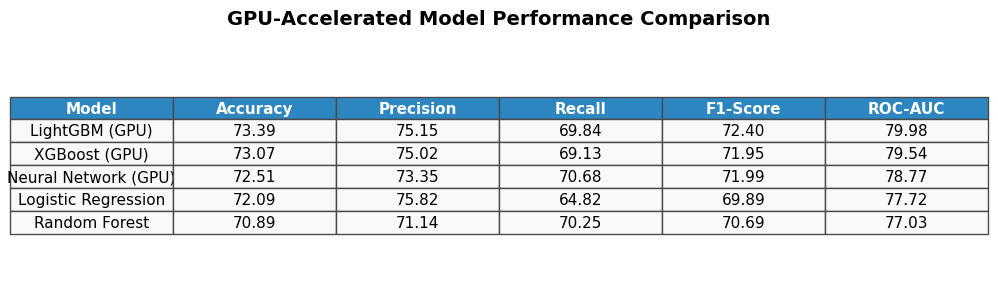

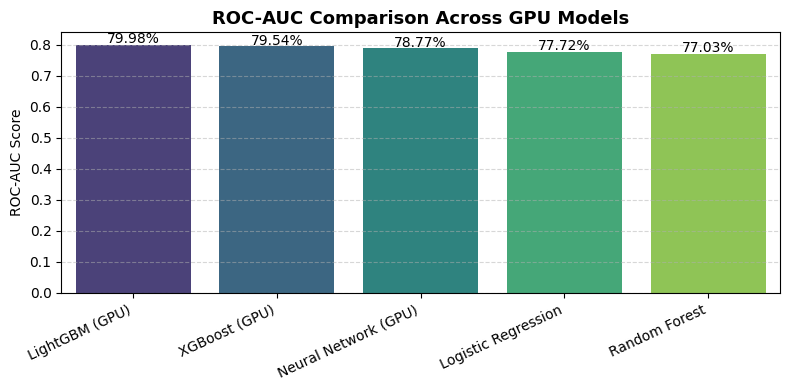

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv("/kaggle/input/heartdatasetclinical/cardio_train.csv", sep=';')

# Drop ID column if present
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Feature engineering
df['age_years'] = (df['age'] / 365).round(1)
df['bmi'] = (df['weight'] / ((df['height']/100)**2)).round(2)
df['bp_diff'] = df['ap_hi'] - df['ap_lo']
df['is_high_bp'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)

# Select features and target
X = df[['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
        'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'bp_diff', 'is_high_bp']]
y = df['cardio']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost (GPU)": XGBClassifier(
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    "LightGBM (GPU)": LGBMClassifier(
        device='gpu',
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Prepare tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=1024, shuffle=True)

# Train NN
model_nn = SimpleNN(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

for epoch in range(10):  # lightweight but efficient
    model_nn.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_nn(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

model_nn.eval()
with torch.no_grad():
    y_prob_nn = model_nn(X_test_t).cpu().numpy().flatten()
    y_pred_nn = (y_prob_nn > 0.5).astype(int)


results = []

# Add NN results first
results.append({
    "Model": "Neural Network (GPU)",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "F1-Score": f1_score(y_test, y_pred_nn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nn)
})

# Other ML models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df.reset_index(drop=True, inplace=True)


plt.figure(figsize=(10, 3))
plt.axis('off')

table_data = results_df.copy()
table_data.iloc[:, 1:] = table_data.iloc[:, 1:].applymap(lambda x: f"{x*100:.2f}")

mpl_table = plt.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(11)
mpl_table.scale(1.2, 1.4)

# Style
for k, cell in mpl_table.get_celld().items():
    cell.set_edgecolor("#4A4A4A")
    cell.set_linewidth(1.0)
    if k[0] == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#2E86C1")
    else:
        cell.set_facecolor("#F8F9F9")

plt.title("GPU-Accelerated Model Performance Comparison", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("gpu_model_comparison_table.png", dpi=400, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette="viridis")

for index, value in enumerate(results_df['ROC-AUC']):
    plt.text(index, value + 0.005, f"{value*100:.2f}%", ha='center', fontsize=10)

plt.xticks(rotation=25, ha='right', fontsize=10)
plt.title("ROC-AUC Comparison Across GPU Models", fontsize=13, fontweight='bold')
plt.ylabel("ROC-AUC Score")
plt.xlabel("")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("gpu_roc_auc_comparison.png", dpi=400)
plt.show()


✅ Using device: cuda
[LightGBM] [Info] Number of positive: 27983, number of negative: 28017
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1067
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 14
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (0.64 MB) transferred to GPU in 0.001199 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499696 -> initscore=-0.001214
[LightGBM] [Info] Start training from score -0.001214
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

Default metric period is 5 because AUC is/are not implemented for GPU


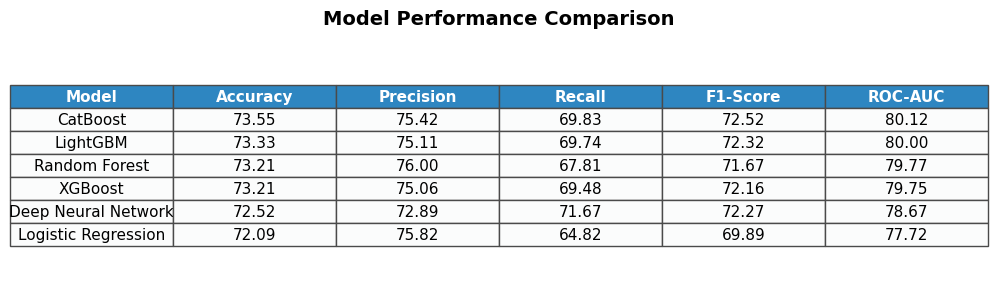

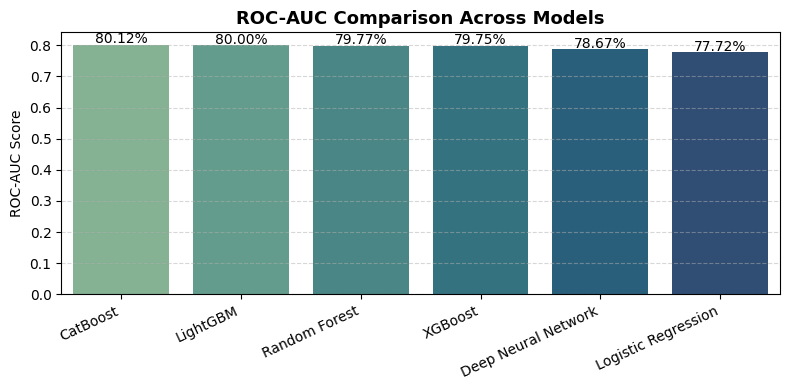

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv("/kaggle/input/heartdatasetclinical/cardio_train.csv", sep=';')

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

df['age_years'] = (df['age'] / 365).round(1)
df['bmi'] = (df['weight'] / ((df['height']/100)**2)).round(2)
df['bp_diff'] = df['ap_hi'] - df['ap_lo']
df['is_high_bp'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)

X = df[['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
        'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'bp_diff', 'is_high_bp']]
y = df['cardio']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "LightGBM": LGBMClassifier(
        device='gpu',
        n_estimators=400,
        learning_rate=0.03,
        max_depth=8,
        num_leaves=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        n_estimators=400,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=400,
        learning_rate=0.03,
        depth=8,
        loss_function='Logloss',
        eval_metric='AUC',
        task_type="GPU",
        verbose=0,
        random_seed=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(max_iter=600, random_state=42)
}

class DeepNN(nn.Module):
    def __init__(self, input_dim):
        super(DeepNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=1024, shuffle=True)

model_nn = DeepNN(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model_nn.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

for epoch in range(12):
    model_nn.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_nn(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
    scheduler.step()

model_nn.eval()
with torch.no_grad():
    y_prob_nn = model_nn(X_test_t).cpu().numpy().flatten()
    y_pred_nn = (y_prob_nn > 0.5).astype(int)

results = []

results.append({
    "Model": "Deep Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "F1-Score": f1_score(y_test, y_pred_nn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nn)
})

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df.reset_index(drop=True, inplace=True)

plt.figure(figsize=(10, 3))
plt.axis('off')

table_data = results_df.copy()
table_data.iloc[:, 1:] = table_data.iloc[:, 1:].applymap(lambda x: f"{x*100:.2f}")

mpl_table = plt.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(11)
mpl_table.scale(1.2, 1.4)

# Style
for k, cell in mpl_table.get_celld().items():
    cell.set_edgecolor("#4A4A4A")
    cell.set_linewidth(1.0)
    if k[0] == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#2E86C1")
    else:
        cell.set_facecolor("#FBFCFC")

plt.title("Model Performance Comparison", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("improved_model_comparison_table.png", dpi=400, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette="crest")

for index, value in enumerate(results_df['ROC-AUC']):
    plt.text(index, value + 0.005, f"{value*100:.2f}%", ha='center', fontsize=10)

plt.xticks(rotation=25, ha='right', fontsize=10)
plt.title("ROC-AUC Comparison Across Models", fontsize=13, fontweight='bold')
plt.ylabel("ROC-AUC Score")
plt.xlabel("")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("improved_roc_auc_comparison.png", dpi=400)
plt.show()


Epoch [1/80] - Loss: 0.5748 | ROC-AUC: 0.7784
Epoch [2/80] - Loss: 0.5646 | ROC-AUC: 0.7804
Epoch [3/80] - Loss: 0.5615 | ROC-AUC: 0.7813
Epoch [4/80] - Loss: 0.5590 | ROC-AUC: 0.7859
Epoch [5/80] - Loss: 0.5565 | ROC-AUC: 0.7847
Epoch [6/80] - Loss: 0.5527 | ROC-AUC: 0.7918
Epoch [7/80] - Loss: 0.5505 | ROC-AUC: 0.7907
Epoch [8/80] - Loss: 0.5482 | ROC-AUC: 0.7937
Epoch [9/80] - Loss: 0.5475 | ROC-AUC: 0.7909
Epoch [10/80] - Loss: 0.5469 | ROC-AUC: 0.7946
Epoch [11/80] - Loss: 0.5454 | ROC-AUC: 0.7960
Epoch [12/80] - Loss: 0.5452 | ROC-AUC: 0.7939
Epoch [13/80] - Loss: 0.5450 | ROC-AUC: 0.7943
Epoch [14/80] - Loss: 0.5451 | ROC-AUC: 0.7890
Epoch [15/80] - Loss: 0.5446 | ROC-AUC: 0.7919
Epoch [16/80] - Loss: 0.5444 | ROC-AUC: 0.7947
Epoch [17/80] - Loss: 0.5433 | ROC-AUC: 0.7916
Epoch [18/80] - Loss: 0.5429 | ROC-AUC: 0.7925
Epoch [19/80] - Loss: 0.5429 | ROC-AUC: 0.7926
Epoch [20/80] - Loss: 0.5429 | ROC-AUC: 0.7903
Epoch [21/80] - Loss: 0.5424 | ROC-AUC: 0.7980
Epoch [22/80] - Loss: 

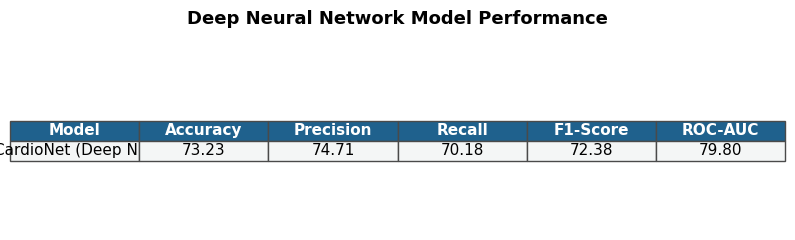

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df = pd.read_csv("/kaggle/input/heartdatasetclinical/cardio_train.csv", sep=';')

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

df['age_years'] = (df['age'] / 365).round(1)
df['bmi'] = (df['weight'] / ((df['height']/100)**2)).round(2)
df['bp_diff'] = df['ap_hi'] - df['ap_lo']
df['is_high_bp'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)

X = df[['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
        'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'bp_diff', 'is_high_bp']]
y = df['cardio'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=256)

class CardioNet(nn.Module):
    def __init__(self, input_dim):
        super(CardioNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CardioNet(X_train.shape[1]).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

epochs = 80
best_auc = 0
patience = 10
no_improve = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t.to(device)).cpu().numpy()
    auc = roc_auc_score(y_test, preds)
    scheduler.step(auc)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {total_loss/len(train_dl):.4f} | ROC-AUC: {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "best_cardionet.pt")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(torch.load("best_cardionet.pt"))
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_t.to(device)).cpu().numpy()
    y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

results_df = pd.DataFrame([{
    "Model": "CardioNet (Deep NN)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-Score": f1,
    "ROC-AUC": roc
}])

plt.figure(figsize=(8, 2.5))
plt.axis('off')

table_data = results_df.copy()
table_data.iloc[:, 1:] = table_data.iloc[:, 1:].applymap(lambda x: f"{x*100:.2f}")

mpl_table = plt.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)

mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(11)
mpl_table.scale(1.2, 1.3)

for k, cell in mpl_table.get_celld().items():
    cell.set_edgecolor("#4A4A4A")
    if k[0] == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#1F618D")
    else:
        cell.set_facecolor("#F4F6F6")

plt.title("Deep Neural Network Model Performance", fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("deep_model_performance.png", dpi=400, bbox_inches='tight')
plt.show()
